## Complete Case Analysis (CCA)

### 1. Definition
Complete Case Analysis (CCA), also known as **listwise deletion**, is a method for handling missing data where **any observation (row) containing a missing value in any variable is completely removed from the dataset** before analysis.
This means that only rows with **no missing values at all** are used for model training or statistical analysis.

## 2. Assumption
CCA works properly only under the assumption that the data is **Missing Completely at Random (MCAR)**.

- **MCAR** means that the probability of a value being missing is **not related to any other variable or the missing value itself**.
- In simple terms, the missing data occurs **purely by chance** and does not follow any pattern.

If this assumption is violated, the results obtained from CCA may become **biased**.

## 3. Advantages

- **Simple to implement** – It requires no complex preprocessing or imputation methods.
- **Easy to understand** – The dataset becomes clean because only complete observations remain.
- **Unbiased estimates** – If the MCAR assumption is satisfied, CCA can provide statistically unbiased results.
- **No imputation errors** – Since missing values are removed instead of estimated, there is no risk of incorrect imputation.

## 4. Disadvantages

- **Loss of data** – Removing rows with missing values can significantly reduce the dataset size.
- **Reduced statistical power** – With fewer observations, the model may become less reliable.
- **Potential bias** – If the data is not MCAR, the remaining dataset may no longer represent the true population.
- **Poor for production systems** – The model does not learn how to handle missing values, which may appear in real-world data during deployment.

## 5. When to Use CCA

CCA is generally recommended only when:

- The **percentage of missing data is very small**, typically **less than 5% of the total dataset**.
- The missing data is **Missing Completely at Random (MCAR)**.
- The dataset is **large enough** that removing a few rows will not significantly affect the analysis.

If missing data is larger than this threshold, **imputation techniques** such as mean/median imputation, KNN imputation, or model-based imputation are usually preferred.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt

In [2]:
df = pd.read_csv("data_science_job.csv")

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [4]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [5]:
df.shape

(19158, 13)

In [6]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and  df[var].isnull().mean() > 0]

cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [8]:
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
2493,9035,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,3.0,NaN,NaN,81.0,0.0
14005,25593,city_103,0.920,Male,Has relevent experience,Full time course,Graduate,STEM,5.0,<10,Early Stage Startup,54.0,0.0
9207,5919,city_16,0.910,NaN,Has relevent experience,no_enrollment,Masters,Humanities,3.0,50-99,Pvt Ltd,139.0,1.0
14537,7994,city_114,0.926,Male,Has relevent experience,Full time course,Graduate,STEM,9.0,5000-9999,Public Sector,96.0,0.0
967,23981,city_160,0.920,NaN,No relevent experience,no_enrollment,Phd,Humanities,20.0,1000-4999,Public Sector,NaN,0.0


In [9]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [10]:
new_df = df[cols].dropna()

new_df.shape, df.shape

((17182, 5), (19158, 13))

Here we plot a histogram of `new_df` so we show the distribution of data after CCA.


array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

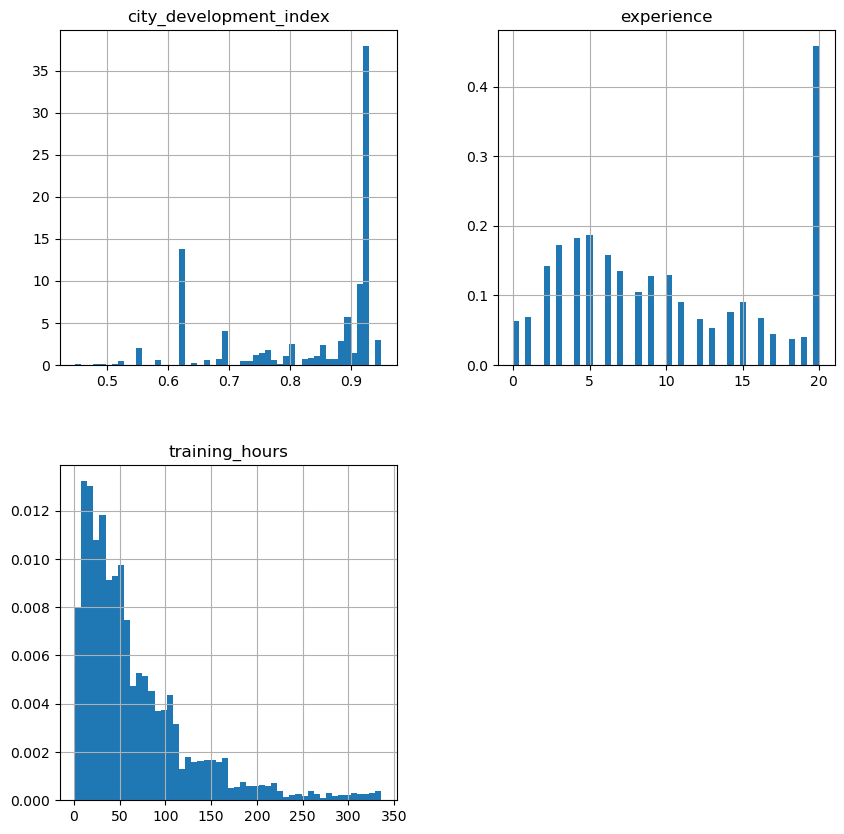

In [12]:
new_df.hist(bins=50, density=True, figsize=(10,10))

Now we compare the original data and CCA performed data to check the distribution and density of values.

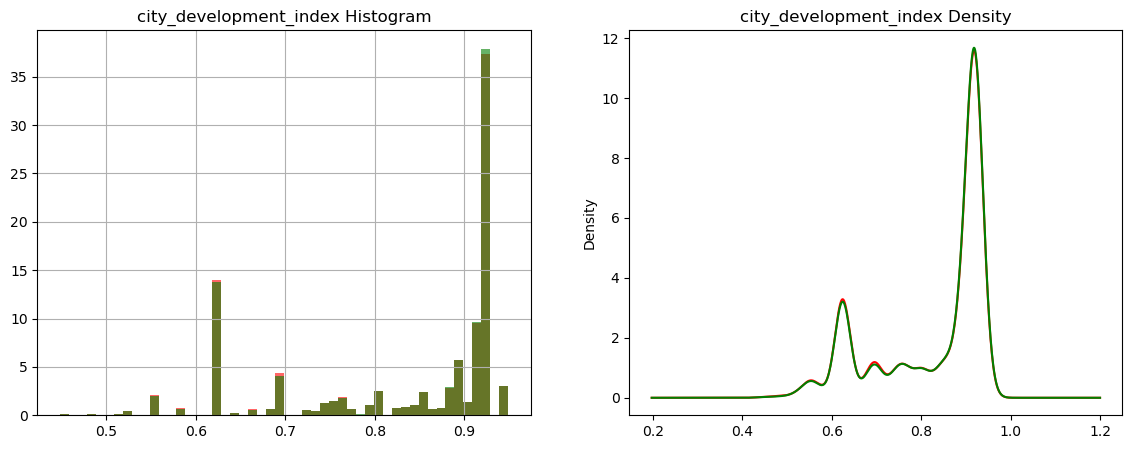

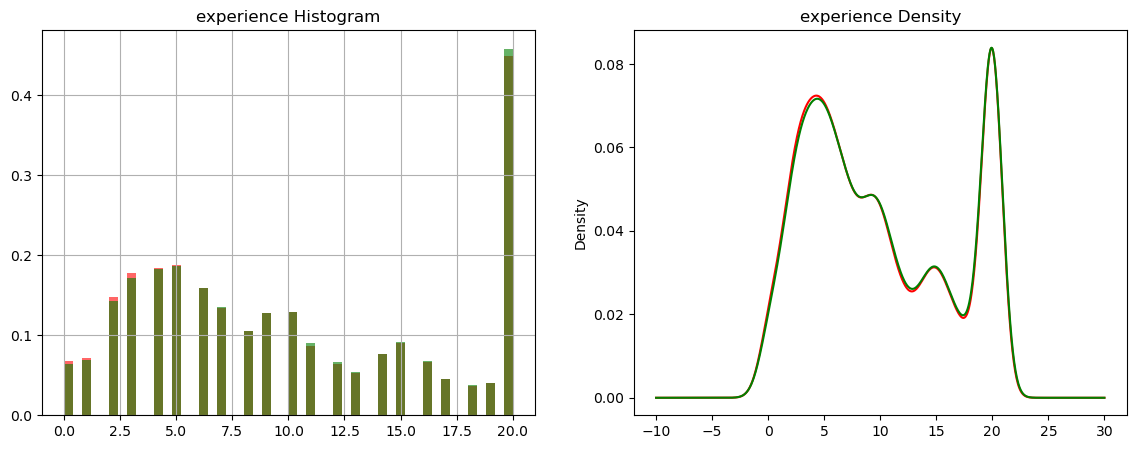

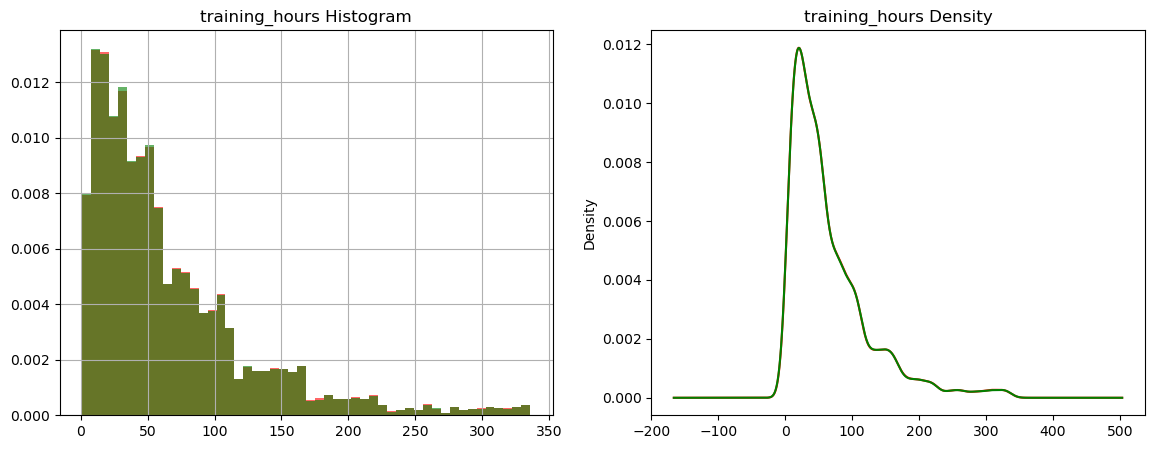

In [28]:
num_cols = [col for col in cols if df[col].dtype in ['int64', 'float64']]

for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(14,5))

    # Histogram comparison
    ax[0].set_title(f'{col} Histogram')
    df[col].hist(bins=50, ax=ax[0], density=True, color='red', alpha=0.6)
    new_df[col].hist(bins=50, ax=ax[0], density=True, color='green', alpha=0.6)

    # Density comparison
    ax[1].set_title(f'{col} Density')
    df[col].plot.density(ax=ax[1], color='red')
    new_df[col].plot.density(ax=ax[1], color='green')

    plt.show()

**Observation: There are slightly difference or say that little bit overlay of the `new_df` which seen in red and other data value are overlap means it accurate.**

For categorical values we have to check the ratio of the column in CCA performed data as same as original data.

In [29]:
temp  = pd.concat(
    [   # percentage of observations per category, original data
        df["enrolled_university"].value_counts() / len(df),

        # percentage of observations per category, cca data
        new_df["enrolled_university"].value_counts() / len(new_df)
    ],
    axis=1 )

# add column names
temp.columns = ["original",'cca']

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [30]:
temp  = pd.concat(
    [   # percentage of observations per category, original data
        df["education_level"].value_counts() / len(df),

        # percentage of observations per category, cca data
        new_df["education_level"].value_counts() / len(new_df)
    ],
    axis=1 )

# add column names
temp.columns = ["original",'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587


**Observation : There are just little bit difference in all values so it will be good. But when the ratio difference after CCA is high so there are something wrong and might you dont apply CCA on it.**